In [1]:
import torch
from rdkit import Chem

from chembed.errors import configure_warning_filters
configure_warning_filters()

from chembed import checkpoint_utils
from chembed import encode as enc
from chembed import decode as dec

In [2]:
# load VAE
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
vae = checkpoint_utils.load_vae_from_hub(device)
vae.eval()

SELFIESTransformerVAE(
  (encoder_embedding): Sequential(
    (0): Embedding(341, 512, scale_grad_by_freq=True)
    (1): PositionalEncoding(
      (dropout): Dropout(p=0.1, inplace=False)
    )
  )
  (transformer_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-5): 6 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=512, out_features=512, bias=True)
        )
        (linear1): Linear(in_features=512, out_features=1024, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=1024, out_features=512, bias=True)
        (norm1): LayerNorm((512,), eps=0.01, elementwise_affine=True)
        (norm2): LayerNorm((512,), eps=0.01, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (transformer_decoder): TransformerDecoder(
    (layers): ModuleList(
      (0-5): 6

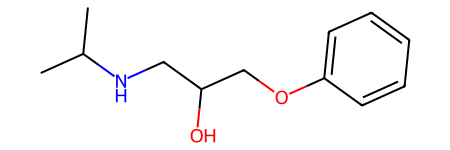

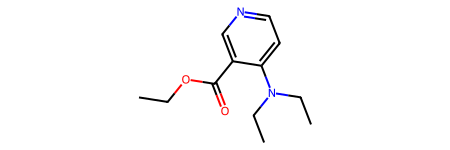

In [3]:
# molecules to interpolate
smiles1 = 'CC(C)NCC(O)COC1=CC=CC=C1'
smiles2 = 'CCOC(=O)C1=CN=CC=C1N(CC)CC'

display(Chem.MolFromSmiles(smiles1))
display(Chem.MolFromSmiles(smiles2))

In [4]:
# encode molecules
zs_ref = enc.encode_multiple_smiles([smiles1, smiles2], vae)

lambda=0.000 CC(C)NCC(O)COC1=CC=CC=C1


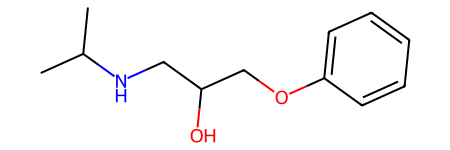

lambda=0.100 CC(C)NCC(O)COC1=CC=CC=C1


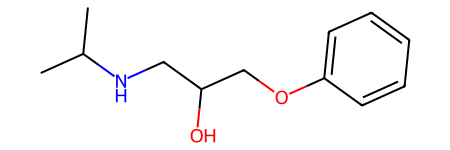

lambda=0.200 CC(C)NCC(O)COC1=CC=CC=C1


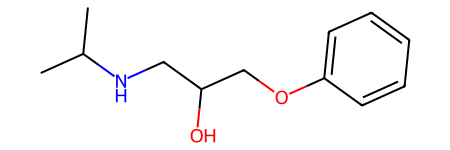

lambda=0.300 CC(C)NCC(O)COC1=CC=CC=C1


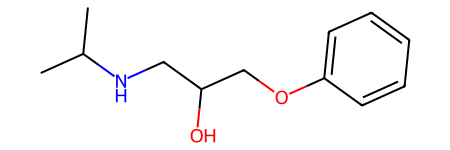

lambda=0.400 CCN(C)C(=O)OCNC1=CC=CC=C1


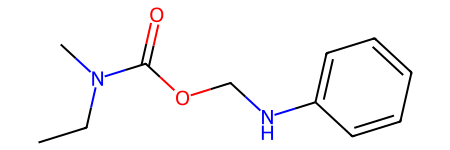

lambda=0.500 CCOC(=O)N(C)COC1=CC=CC=C1


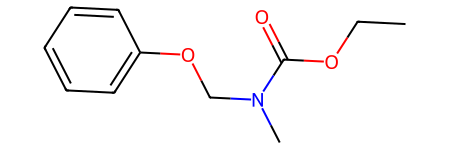

lambda=0.600 CCOC(=O)N(C)COC1=CC=CC=C1C


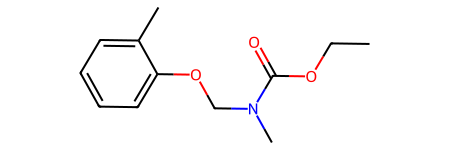

lambda=0.700 CCOC(=O)C1=CN=CC=C1N(CC)CC


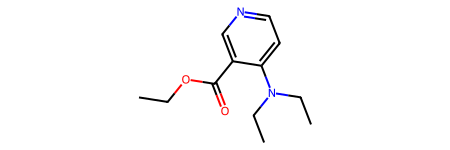

lambda=0.800 CCOC(=O)C1=CN=CC=C1N(CC)CC


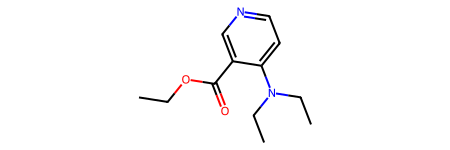

lambda=0.900 CCOC(=O)C1=CN=CC=C1N(CC)CC


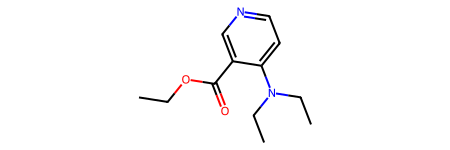

lambda=1.000 CCOC(=O)C1=CN=CC=C1N(CC)CC


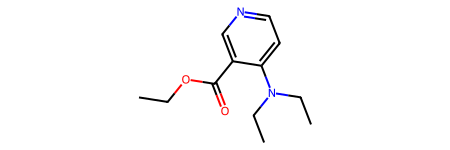

In [5]:
# perform interpolations
ls = torch.arange(0, 1.01, 0.1).view(-1, 1, 1)
zs_interp = (1 - ls) * zs_ref[0] + ls * zs_ref[1]
smiles_interp = dec.decode_zs_to_smiles(zs_interp, vae)

for l, smiles in zip(ls, smiles_interp):
    print(f"lambda={l.item():.3f}", smiles)
    display(Chem.MolFromSmiles(smiles))